<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/cap3/nodo_cero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import samplers
importlib.reload(samplers)
from samplers import (
    transicion_compuesta,
    recocido_simulado_log
)

import aux
importlib.reload(aux)
from aux import (
    log_pdf_objetivo_nodo_cero,
    log_pdf_propuesta_nodo_cero,
    generador_guiado_nodo_cero,
    generador_random_walk_nodo_cero,
    nodo_bajo_grado
)

from collections import Counter
from scipy.sparse.csgraph import shortest_path

import numpy as np
import matplotlib.pyplot as plt
import random
import networkx as nx
from google.colab import files

/content/MCMC-MonteCarlo-TFG
Already up to date.
/content


In [34]:
rng = np.random.default_rng(seed=1)

num_nodos = 5000

G = nx.watts_strogatz_graph(n=num_nodos, k=4, p=0.02, seed=1)

matriz_adyacencia = nx.to_scipy_sparse_array(G)
matriz_distancias = shortest_path(csgraph=matriz_adyacencia, directed=False, method='D')

paciente_cero_real = rng.choice(list(G.nodes()))
velocidad_propagacion = 2

tiempos_infeccion_reales = matriz_distancias[paciente_cero_real, :] * velocidad_propagacion

ratio_observacion = 0.02
nodos_observados = random.sample(list(G.nodes()), int(num_nodos * ratio_observacion))

media = 0
desviacion = 0.5
tiempos_observados = {nodo: max(0, tiempos_infeccion_reales[nodo] + rng.normal(media, desviacion)) for nodo in nodos_observados}

indices_obs = np.array(list(tiempos_observados.keys()))
valores_obs = np.array(list(tiempos_observados.values()))

In [35]:
diccionario_centralidad = nx.degree_centrality(G)
valores_centralidad = np.array([diccionario_centralidad[i] for i in range(num_nodos)])

indices_observados = list(nodos_observados)

distancias_minimas = np.min(matriz_distancias[:, indices_observados], axis=1)

pesos_proximidad = 1.0 / (1.0 + distancias_minimas)
probabilidades_salto = valores_centralidad * pesos_proximidad
probabilidades_salto = probabilidades_salto / np.sum(probabilidades_salto)

In [36]:
log_pdf_objetivo = lambda estado: log_pdf_objetivo_nodo_cero(
    estado,
    matriz_distancias,
    indices_obs,
    velocidad_propagacion,
    valores_obs,
    desviacion
)

log_pdf_propuesta = lambda propuesto, actual: log_pdf_propuesta_nodo_cero(
    propuesto,
    actual,
    probabilidades_salto,
    G,
    0.15
)

generador_guiado = lambda nodo, rng: generador_guiado_nodo_cero(
    nodo,
    rng,
    probabilidades_salto,
    G
)

generador_random_walk = lambda nodo, rng: generador_random_walk_nodo_cero(
    nodo,
    rng,
    G
)

transiciones_base = [generador_random_walk, generador_guiado]
alfas = [0.85, 0.15]
generador_propuesta = transicion_compuesta(transiciones_base, alfas)

nodo_inicial = nodo_bajo_grado(G)
nodo_inferido, historial_energia, historial_estados = recocido_simulado_log(
    nodo_inicial,
    log_pdf_objetivo,
    generador_propuesta,
    log_pdf_propuesta,
    15000,
    100.0,
    0.9992
)

Nodo Cero Real     : 2365
Nodo Cero Inferido : 2365
Distancia en saltos entre inferido y real: 0.0


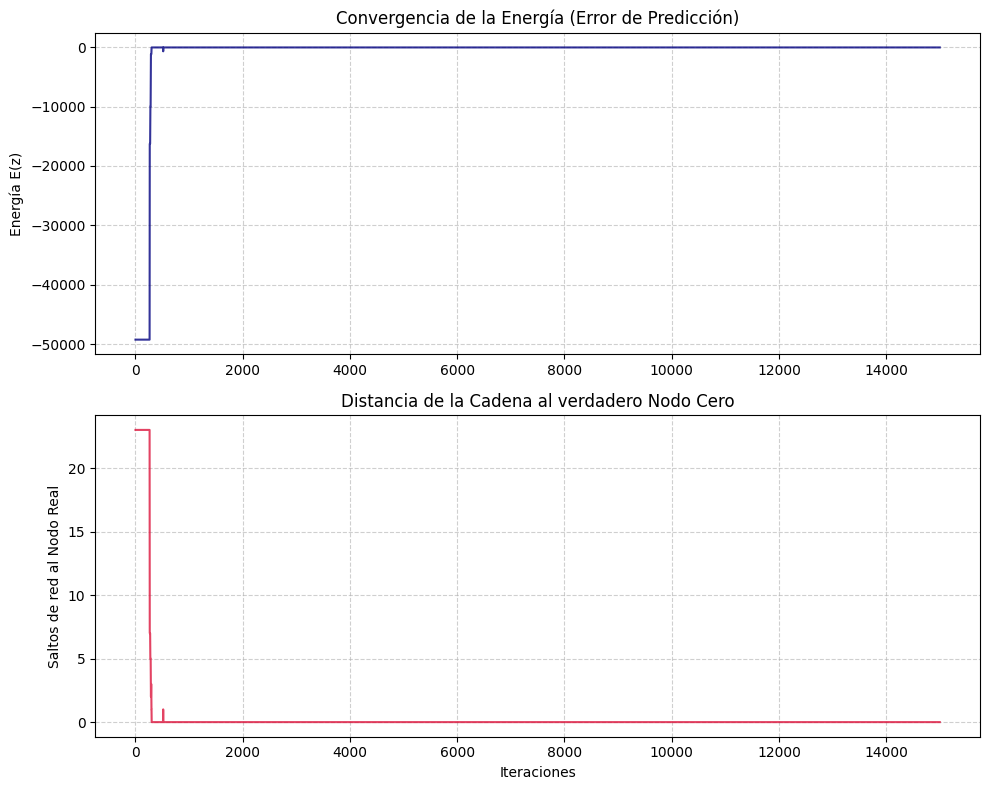

In [37]:
print(f"Nodo Cero Real     : {paciente_cero_real}")
print(f"Nodo Cero Inferido : {nodo_inferido}")
print(f"Distancia en saltos entre inferido y real: {matriz_distancias[nodo_inferido, paciente_cero_real]}")

historial_distancias = matriz_distancias[historial_estados, paciente_cero_real]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(- np.array(historial_energia), color='navy', alpha=0.8)
ax1.set_title('Convergencia de la Energía (Error de Predicción)', fontsize=12)
ax1.set_ylabel('Energía E(z)')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(historial_distancias, color='crimson', alpha=0.8)
ax2.set_title('Distancia de la Cadena al verdadero Nodo Cero', fontsize=12)
ax2.set_xlabel('Iteraciones')
ax2.set_ylabel('Saltos de red al Nodo Real')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('CIBERSEGURIDAD.pdf')
plt.show()

In [38]:
files.download("CIBERSEGURIDAD.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>